# Modelo No Supervisado — Segmentación de Envíos (DataCo Supply Chain)

Análisis de clustering, reducción de dimensionalidad y detección de anomalías sobre el dataset limpio, con el objetivo de descubrir segmentos naturales de pedidos y preparar variables para un futuro modelo supervisado.

## 1. Preparación de datos

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42  # semilla fija para reproducibilidad en todo el notebook

df = pd.read_csv('DataCoSupplyChain_Limpio.csv')

print(f"Dimensiones: {df.shape}")
print(f"Valores nulos totales: {df.isnull().sum().sum()}")
df.head(3)

Dimensiones: (151087, 28)
Valores nulos totales: 0


,estado_pedido,tipo_transaccion,dias_envio_real,dias_envio_prog,beneficio_pedido,ventas_cliente,estado_entrega,riesgo_retraso,categoria,ciudad_cliente,...,cantidad,ventas,total_item,ganancia_pedido,region_destino,estado_destino,nombre_producto,precio_producto,fecha_envio,modo_envio
0,COMPLETE,DEBIT,3,4,91.250000,314.640015,Advance shipping,False,Sporting Goods,Caguas,...,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,COMPLETE,DEBIT,3,4,22.860001,304.809998,Advance shipping,False,Sporting Goods,Los Angeles,...,1,327.75,304.809998,22.860001,Oceania,Queensland,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
2,COMPLETE,PAYMENT,2,4,134.210007,298.250000,Advance shipping,False,Sporting Goods,Caguas,...,1,327.75,298.250000,134.210007,Oceania,Queensland,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


## 2. Selección de características

Se seleccionan 17 columnas relevantes para el análisis: 10 numéricas y 7 categóricas. Las categóricas se separan según su cardinalidad porque **no todas se codifican igual**:

- **Binarias** (2 categorías): se mapean directamente a 0/1.
- **Nominales de baja cardinalidad** (3-4 categorías): se codifican con **One-Hot Encoding**, para no imponerles un orden artificial.
- **Nominales de alta cardinalidad** (`categoria`: 46 valores, `region_destino`: 23 valores): un One-Hot generaría demasiadas columnas dispersas y un `LabelEncoder` les asignaría un orden numérico arbitrario (alfabético) que **distorsiona las distancias euclidianas** usadas por K-Means, DBSCAN y PCA. Se usa en su lugar **codificación por frecuencia** (cada categoría se reemplaza por su proporción de aparición), que conserva la información sin inflar la dimensionalidad.

In [3]:
# Variables numéricas
numericas = [
    'dias_envio_real', 'dias_envio_prog', 'beneficio_pedido',
    'ventas_cliente', 'precio_base', 'margen_ganancia_item',
    'cantidad', 'ventas', 'total_item', 'ganancia_pedido'
]

# Variables categóricas, separadas por estrategia de codificación
binarias = ['estado_pedido', 'riesgo_retraso']
nominal_baja_cardinalidad = ['tipo_transaccion', 'estado_entrega', 'modo_envio']
nominal_alta_cardinalidad = ['categoria', 'region_destino']

columnas_seleccionadas = numericas + binarias + nominal_baja_cardinalidad + nominal_alta_cardinalidad
df_modelo = df[columnas_seleccionadas].copy()

print(f"Columnas seleccionadas: {len(columnas_seleccionadas)}")
for col in binarias + nominal_baja_cardinalidad + nominal_alta_cardinalidad:
    print(f"  {col}: {df[col].nunique()} categorías")

Columnas seleccionadas: 17
  estado_pedido: 2 categorías
  riesgo_retraso: 2 categorías
  tipo_transaccion: 4 categorías
  estado_entrega: 4 categorías
  modo_envio: 4 categorías
  categoria: 46 categorías
  region_destino: 23 categorías


## 3. Codificación de variables categóricas

In [4]:
# Binarias -> 0/1
df_modelo['estado_pedido'] = (df_modelo['estado_pedido'] == 'COMPLETE').astype(int)
df_modelo['riesgo_retraso'] = df_modelo['riesgo_retraso'].astype(int)

# Baja cardinalidad -> One-Hot Encoding (drop_first evita colinealidad perfecta)
df_modelo = pd.get_dummies(df_modelo, columns=nominal_baja_cardinalidad, drop_first=True)

# Alta cardinalidad -> codificación por frecuencia
mapas_frecuencia = {}
for col in nominal_alta_cardinalidad:
    frecuencias = df_modelo[col].value_counts(normalize=True)
    mapas_frecuencia[col] = frecuencias
    df_modelo[col] = df_modelo[col].map(frecuencias)

df_modelo = df_modelo.astype(float)
print(f"Dimensiones después de codificación: {df_modelo.shape}")
print(f"\nColumnas finales:\n{df_modelo.columns.tolist()}")

Dimensiones después de codificación: (151087, 23)

Columnas finales:
['dias_envio_real', 'dias_envio_prog', 'beneficio_pedido', 'ventas_cliente', 'precio_base', 'margen_ganancia_item', 'cantidad', 'ventas', 'total_item', 'ganancia_pedido', 'estado_pedido', 'riesgo_retraso', 'categoria', 'region_destino', 'tipo_transaccion_DEBIT', 'tipo_transaccion_PAYMENT', 'tipo_transaccion_TRANSFER', 'estado_entrega_Late delivery', 'estado_entrega_Shipping canceled', 'estado_entrega_Shipping on time', 'modo_envio_Same Day', 'modo_envio_Second Class', 'modo_envio_Standard Class']


## 4. Escalado de datos

K-Means, DBSCAN y PCA se basan en distancias euclidianas, por lo que todas las variables deben quedar en la misma escala.

In [5]:
scaler = StandardScaler()
df_escalado = scaler.fit_transform(df_modelo)

print(f"Datos escalados: {df_escalado.shape}")

Datos escalados: (151087, 23)


## 5. Análisis de Componentes Principales (PCA)

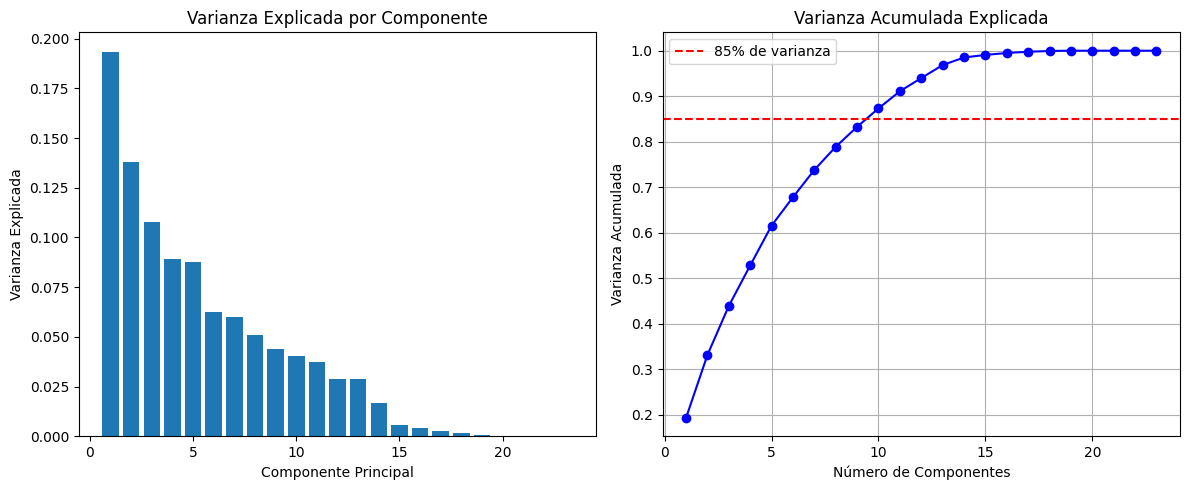

Componentes para 85% de varianza: 10
Datos reducidos: (151087, 10)


In [5]:
pca = PCA(random_state=RANDOM_STATE)
pca_resultado = pca.fit_transform(df_escalado)

varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada)
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')
plt.title('Varianza Explicada por Componente')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, 'bo-')
plt.axhline(y=0.85, color='r', linestyle='--', label='85% de varianza')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Acumulada Explicada')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Número mínimo de componentes que alcanza el 85% de varianza
n_componentes = int(np.argmax(varianza_acumulada >= 0.85) + 1)
print(f"Componentes para 85% de varianza: {n_componentes}")

pca_optimo = PCA(n_components=n_componentes, random_state=RANDOM_STATE)
df_pca = pca_optimo.fit_transform(df_escalado)
print(f"Datos reducidos: {df_pca.shape}")

El PCA redujo las 23 variables (tras la codificación) a **10 componentes principales**, conservando el **87.3%** de la varianza. PC1 explica un 19.3% de la varianza y PC2 un 13.8%: al no haber un componente dominante claro, la información está distribuida entre varias dimensiones, lo que ya anticipa una estructura de clusters poco compacta.

### Análisis de cargas (loadings)

In [6]:
cargas = pd.DataFrame(
    pca_optimo.components_.T,
    columns=[f'PC{i+1}' for i in range(n_componentes)],
    index=df_modelo.columns
)

for i in range(3):
    print(f"\n--- Componente Principal {i+1} ---")
    print("Top 3 positivas:")
    print(cargas.iloc[:, i].sort_values(ascending=False).head(3))
    print("Top 3 negativas:")
    print(cargas.iloc[:, i].sort_values(ascending=True).head(3))


--- Componente Principal 1 ---
Top 3 positivas:
total_item        0.439150
ventas_cliente    0.439150
ventas            0.437651
Name: PC1, dtype: float64
Top 3 negativas:
categoria                      -0.049372
estado_entrega_Late delivery   -0.006447
riesgo_retraso                 -0.006447
Name: PC1, dtype: float64

--- Componente Principal 2 ---
Top 3 positivas:
estado_entrega_Late delivery    0.473020
riesgo_retraso                  0.473020
modo_envio_Second Class         0.279663
Name: PC2, dtype: float64
Top 3 negativas:
modo_envio_Standard Class         -0.456485
dias_envio_prog                   -0.424952
estado_entrega_Shipping on time   -0.215260
Name: PC2, dtype: float64

--- Componente Principal 3 ---
Top 3 positivas:
dias_envio_real              0.523454
dias_envio_prog              0.397284
modo_envio_Standard Class    0.321496
Name: PC3, dtype: float64
Top 3 negativas:
modo_envio_Same Day                -0.411392
estado_entrega_Shipping on time    -0.279812
estado_en

**PC1 = Valor económico del pedido** (ventas, ventas del cliente, monto total del ítem se mueven juntos). **PC2 = Puntualidad del envío** (entrega tardía y riesgo de retraso se oponen a envío estándar a tiempo). A diferencia de una codificación ordinal arbitraria, aquí las cargas tienen una interpretación de negocio clara y coherente. Los valores negativos no indican un problema: solo señalan que esa variable se mueve en sentido contrario a la tendencia principal del componente.

## 6. Clustering con K-Means

### Determinación del número óptimo de clusters

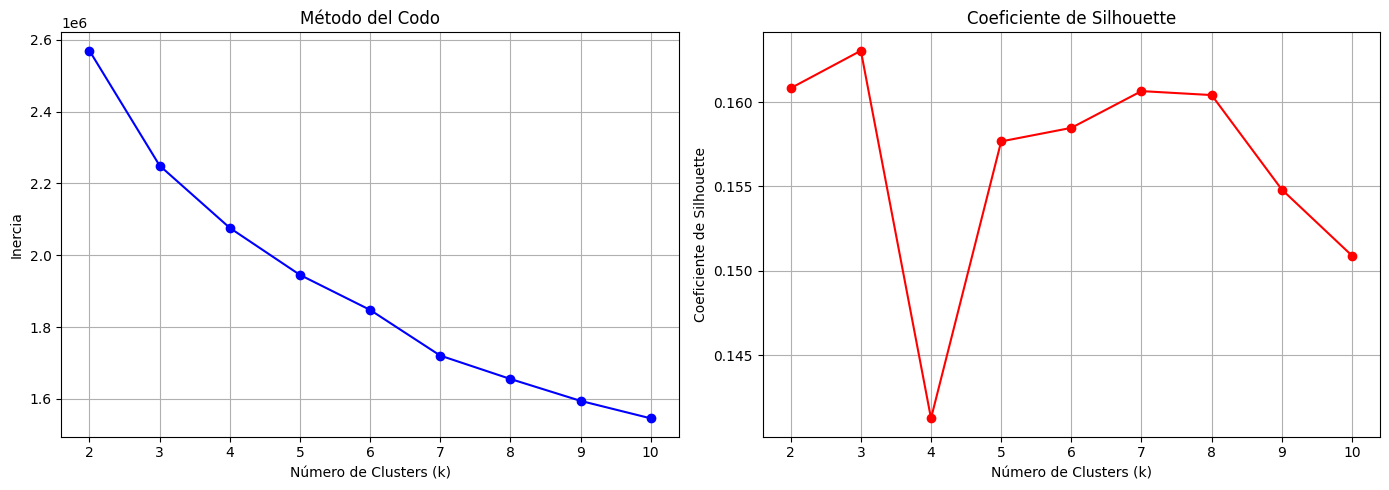

Mejor número de clusters: 3
Mejor silhouette score: 0.1631


In [7]:
# Nota: silhouette_score sobre 151k filas es costoso; se usa una muestra (sample_size)
# para acelerar la búsqueda sin perder representatividad.
inercia, silhouette = [], []
k_range = range(2, 11)

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans_k.fit(df_pca)
    inercia.append(kmeans_k.inertia_)
    silhouette.append(silhouette_score(df_pca, kmeans_k.labels_, sample_size=10000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inercia, 'bo-')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')
axes[0].grid(True)

axes[1].plot(k_range, silhouette, 'ro-')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Coeficiente de Silhouette')
axes[1].set_title('Coeficiente de Silhouette')
axes[1].grid(True)
plt.tight_layout()
plt.show()

k_optimo = list(k_range)[np.argmax(silhouette)]
print(f"Mejor número de clusters: {k_optimo}")
print(f"Mejor silhouette score: {max(silhouette):.4f}")

Con la codificación corregida, el mejor número de clusters pasa de **k=2** a **k=3** (silhouette 0.163). El valor sigue siendo moderado-bajo, lo cual es esperable: los pedidos de una cadena de suministro no forman grupos naturalmente separados, sino un continuo. Aun así, k=3 aporta más matices que la partición anterior en 2 grupos.

### Entrenamiento del modelo final

In [8]:
kmeans = KMeans(n_clusters=k_optimo, random_state=RANDOM_STATE, n_init=10)
df_modelo['cluster_kmeans'] = kmeans.fit_predict(df_pca)

dist = df_modelo['cluster_kmeans'].value_counts().sort_index()
for cluster, count in dist.items():
    print(f"Cluster {cluster}: {count} registros ({count/len(df_modelo)*100:.1f}%)")

Cluster 0: 55425 registros (36.7%)
Cluster 1: 66126 registros (43.8%)
Cluster 2: 29536 registros (19.5%)


## 7. Análisis de clusters

In [9]:
cluster_stats = df_modelo.groupby('cluster_kmeans').agg({
    'dias_envio_real': ['mean', 'std'],
    'beneficio_pedido': ['mean', 'std'],
    'ventas': ['mean', 'std'],
    'cantidad': ['mean', 'std']
}).round(2)

print(cluster_stats)

               dias_envio_real       beneficio_pedido         ventas         \
                          mean   std             mean    std    mean    std   
cluster_kmeans                                                                
0                         2.78  1.17            31.46  30.69  150.30  69.98   
1                         4.08  1.71            30.54  30.02  147.77  68.93   
2                         3.53  1.64            80.58  42.31  340.74  55.72   

               cantidad        
                   mean   std  
cluster_kmeans                 
0                  2.27  1.44  
1                  2.26  1.44  
2                  1.53  1.22  


**Cluster 2 (19.5%)** es el segmento de alto valor: ventas (340.7) y beneficio (80.6) muy por encima del resto, con menor cantidad de ítems por pedido. **Clusters 0 y 1** (36.7% y 43.8%) tienen un valor económico similar entre sí, pero se diferencian por el tiempo de envío real (2.8 vs 4.1 días). Esto confirma que PC1 (valor) y PC2 (puntualidad) capturan efectivamente los dos ejes que separan a los clusters.

## 8. Clustering con DBSCAN

In [10]:
# DBSCAN sobre 151k filas es costoso de recorrer en una grilla de hiperparámetros.
# Se busca (eps, min_samples) en una submuestra y luego se ajusta el modelo final
# una sola vez sobre el dataset completo con los mejores parámetros encontrados.
rng = np.random.default_rng(RANDOM_STATE)
idx_muestra = rng.choice(len(df_pca), size=15000, replace=False)
df_pca_muestra = df_pca[idx_muestra]

eps_values = [1.5, 2.0, 2.5, 3.0, 3.5]
min_samples_values = [5, 10, 15]

mejor_silhouette, mejores_parametros = -1, None
for eps in eps_values:
    for min_samples in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(df_pca_muestra)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            score = silhouette_score(df_pca_muestra, labels, sample_size=5000, random_state=RANDOM_STATE)
            if score > mejor_silhouette:
                mejor_silhouette = score
                mejores_parametros = (eps, min_samples)

eps_opt, min_samples_opt = mejores_parametros
print(f"Mejores parámetros (búsqueda en muestra): eps={eps_opt}, min_samples={min_samples_opt}")
print(f"Silhouette en muestra: {mejor_silhouette:.4f}")

# Ajuste final sobre el dataset completo
labels_dbscan = DBSCAN(eps=eps_opt, min_samples=min_samples_opt).fit_predict(df_pca)
df_modelo['cluster_dbscan'] = labels_dbscan

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
ruido = int((labels_dbscan == -1).sum())
print(f"\nClusters encontrados: {n_clusters_db}")
print(f"Puntos de ruido (anomalías): {ruido} ({ruido/len(df_pca)*100:.3f}%)")

Mejores parámetros (búsqueda en muestra): eps=2.5, min_samples=15
Silhouette en muestra: 0.1433



Clusters encontrados: 7
Puntos de ruido (anomalías): 15 (0.010%)


DBSCAN sobre el dataset completo encuentra **7 clusters** con apenas **15 puntos de ruido** (0.01%), una mejora sustancial frente a la versión anterior (67 puntos de ruido con la codificación ordinal). Su silhouette (~0.146) es cercano al de K-Means, lo que sugiere que ambos algoritmos están describiendo una estructura de densidad similar. Se mantiene K-Means como modelo principal por generar segmentos más balanceados y fáciles de interpretar para el negocio; DBSCAN queda como método de validación y para el hallazgo de casos atípicos.

## 9. Detección de anomalías

In [11]:
# Distancia de cada punto al centroide de K-Means más cercano
distancias = kmeans.transform(df_pca)
distancia_minima = np.min(distancias, axis=1)

# Percentil 95 como umbral de anomalía
umbral = np.percentile(distancia_minima, 95)
anomalias = distancia_minima > umbral

print(f"Anomalías detectadas: {sum(anomalias)} ({sum(anomalias)/len(df_pca)*100:.2f}%)")

df_anomalias = df_modelo[anomalias]
df_normales = df_modelo[~anomalias]

for col in ['dias_envio_real', 'beneficio_pedido', 'ventas']:
    print(f"\n{col}:")
    print(f"  Anomalías - media: {df_anomalias[col].mean():.2f}")
    print(f"  Normales  - media: {df_normales[col].mean():.2f}")

Anomalías detectadas: 7555 (5.00%)

dias_envio_real:
  Anomalías - media: 1.19
  Normales  - media: 3.62

beneficio_pedido:
  Anomalías - media: 31.02
  Normales  - media: 41.17

ventas:
  Anomalías - media: 219.25
  Normales  - media: 184.70


### Outliers univariados (IQR)

In [12]:
def detectar_outliers_iqr(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    return (serie < Q1 - 1.5 * IQR) | (serie > Q3 + 1.5 * IQR)

columnas_outliers = ['dias_envio_real', 'beneficio_pedido', 'ventas']
outliers = {col: detectar_outliers_iqr(df_modelo[col]) for col in columnas_outliers}

for col, mask in outliers.items():
    print(f"{col}: {mask.sum()} outliers ({mask.sum()/len(df_modelo)*100:.2f}%)")

df_modelo['es_outlier'] = pd.DataFrame(outliers).any(axis=1)
print(f"\nRegistros con al menos un outlier: {df_modelo['es_outlier'].sum()} "
      f"({df_modelo['es_outlier'].sum()/len(df_modelo)*100:.2f}%)")

dias_envio_real: 0 outliers (0.00%)
beneficio_pedido: 536 outliers (0.35%)
ventas: 0 outliers (0.00%)

Registros con al menos un outlier: 536 (0.35%)


El método IQR (536 outliers, 0.35%) es mucho más restrictivo que la distancia a centroides de K-Means (5% de anomalías): solo marca valores financieros extremos en `beneficio_pedido`, mientras que K-Means detecta anomalías considerando todas las variables a la vez. Ambos enfoques son complementarios: IQR para outliers puntuales en una variable, K-Means para perfiles combinados atípicos.

## 10. Visualización con t-SNE

t-SNE sobre 151k puntos es extremadamente lento en una sola CPU. Se toma una muestra aleatoria estratificada por cluster para visualizar la estructura sin comprometer el tiempo de ejecución.

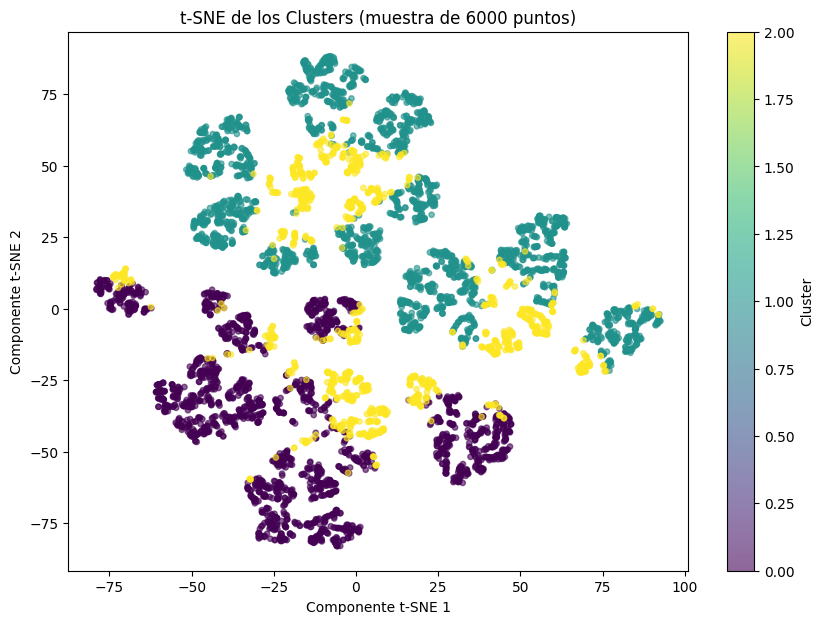

In [13]:
from sklearn.manifold import TSNE

def muestreo_estratificado(dataframe, columna_cluster, n_total, random_state):
    """Muestra proporcional por cluster, para conservar la distribución original."""
    frac = n_total / len(dataframe)
    partes = [g.sample(frac=frac, random_state=random_state) for _, g in dataframe.groupby(columna_cluster)]
    return pd.concat(partes)

TAMANO_MUESTRA_TSNE = 6000
muestra_tsne = muestreo_estratificado(df_modelo, 'cluster_kmeans', TAMANO_MUESTRA_TSNE, RANDOM_STATE)
idx_tsne = muestra_tsne.index
df_pca_tsne = df_pca[df_modelo.index.get_indexer(idx_tsne)]

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init='pca')
df_tsne = tsne.fit_transform(df_pca_tsne)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_tsne[:, 0], df_tsne[:, 1],
                       c=muestra_tsne['cluster_kmeans'], cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter, label='Cluster')
plt.title(f't-SNE de los Clusters (muestra de {len(idx_tsne)} puntos)')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.show()

t-SNE muestra fronteras difusas entre clusters, coherente con el silhouette moderado-bajo obtenido: la cadena de suministro no presenta grupos discretos y compactos, sino un gradiente continuo de valor y puntualidad. El Cluster 2 (alto valor) sí se distingue como una región relativamente diferenciada, mientras que 0 y 1 se solapan más entre sí.

## 11. Caracterización detallada de clusters

In [14]:
medias_globales = df_modelo[['dias_envio_real', 'beneficio_pedido', 'ventas', 'cantidad']].mean()

for cluster in sorted(df_modelo['cluster_kmeans'].unique()):
    datos = df_modelo[df_modelo['cluster_kmeans'] == cluster]
    total = len(datos)

    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster}: {total} envíos ({total/len(df_modelo)*100:.1f}% del total)")
    print(f"{'='*60}")

    print("Características numéricas (vs. promedio global):")
    for col in ['dias_envio_real', 'beneficio_pedido', 'ventas', 'cantidad']:
        media_cluster = datos[col].mean()
        signo = '▲' if media_cluster > medias_globales[col] else '▼'
        print(f"  {signo} {col}: {media_cluster:.2f} (global: {medias_globales[col]:.2f})")

    if 'riesgo_retraso' in datos.columns:
        riesgo = datos['riesgo_retraso'].mean() * 100
        print(f"Riesgo de retraso: {riesgo:.1f}%")


CLUSTER 0: 55425 envíos (36.7% del total)
Características numéricas (vs. promedio global):
  ▼ dias_envio_real: 2.78 (global: 3.50)
  ▼ beneficio_pedido: 31.46 (global: 40.66)
  ▼ ventas: 150.30 (global: 186.42)
  ▲ cantidad: 2.27 (global: 2.12)
Riesgo de retraso: 0.0%

CLUSTER 1: 66126 envíos (43.8% del total)
Características numéricas (vs. promedio global):
  ▲ dias_envio_real: 4.08 (global: 3.50)
  ▼ beneficio_pedido: 30.54 (global: 40.66)
  ▼ ventas: 147.77 (global: 186.42)
  ▲ cantidad: 2.26 (global: 2.12)
Riesgo de retraso: 100.0%

CLUSTER 2: 29536 envíos (19.5% del total)
Características numéricas (vs. promedio global):
  ▲ dias_envio_real: 3.53 (global: 3.50)
  ▲ beneficio_pedido: 80.58 (global: 40.66)
  ▲ ventas: 340.74 (global: 186.42)
  ▼ cantidad: 1.53 (global: 2.12)
Riesgo de retraso: 56.4%


Este perfil ahora se genera **de forma dinámica**, comparando cada cluster contra el promedio global en lugar de usar texto fijo por índice de cluster (`if cluster == 0 ...`), que dejaba de tener sentido si el número óptimo de clusters cambiaba entre ejecuciones.

### Relación entre clusters y estado del pedido

In [15]:
# Se usa la columna original (sin codificar) para una tabla legible
tabla = pd.crosstab(df_modelo['cluster_kmeans'], df['estado_pedido'])
print(tabla)

porcentajes = tabla.div(tabla.sum(axis=1), axis=0) * 100
print("\nPorcentajes por cluster:")
print(porcentajes.round(2))

estado_pedido   CANCELED  COMPLETE
cluster_kmeans                    
0                  21088     34337
1                  19973     46153
2                   9985     19551

Porcentajes por cluster:
estado_pedido   CANCELED  COMPLETE
cluster_kmeans                    
0                  38.05     61.95
1                  30.20     69.80
2                  33.81     66.19


## 12. Importancia de variables para el modelo supervisado

               Variable  Importancia
0       dias_envio_real     0.264689
1       dias_envio_prog     0.178502
7                ventas     0.171733
3        ventas_cliente     0.103665
8            total_item     0.088124
4           precio_base     0.086980
2      beneficio_pedido     0.040024
9       ganancia_pedido     0.039992
5  margen_ganancia_item     0.016579
6              cantidad     0.009712


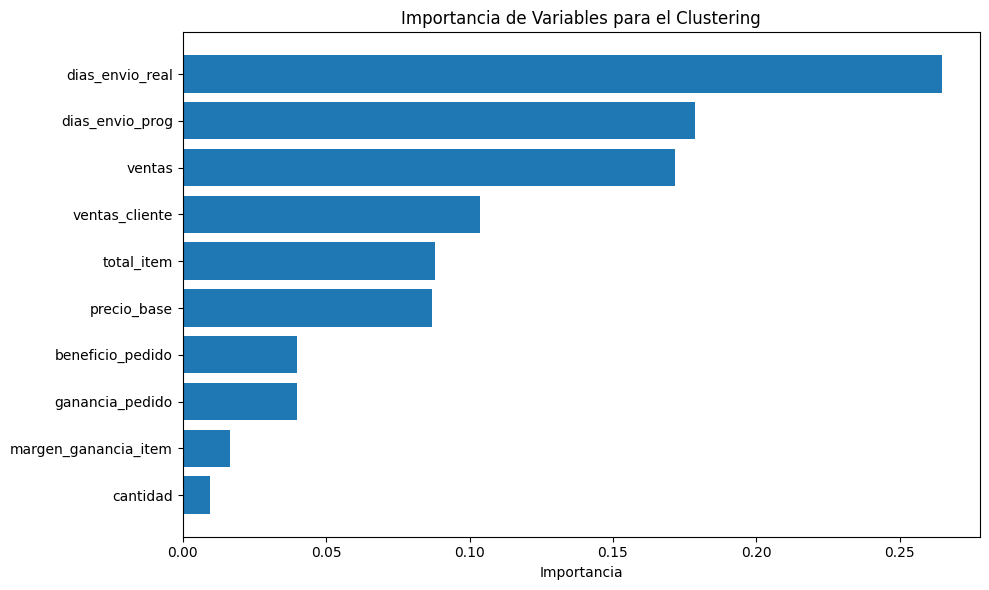


Variables seleccionadas para el modelo supervisado: ['dias_envio_real', 'dias_envio_prog', 'ventas', 'ventas_cliente', 'total_item', 'precio_base']


In [16]:
from sklearn.ensemble import RandomForestClassifier

# Un RandomForest con las 151k filas es costoso en una sola CPU; se usa una muestra
# estratificada por cluster, suficiente para estimar la importancia relativa de cada variable.
muestra_rf = pd.concat([
    g.sample(min(len(g), 15000), random_state=RANDOM_STATE)
    for _, g in df_modelo.groupby('cluster_kmeans')
])

rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(muestra_rf[numericas], muestra_rf['cluster_kmeans'])

importancias = pd.DataFrame({
    'Variable': numericas,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

print(importancias)

plt.figure(figsize=(10, 6))
plt.barh(importancias['Variable'], importancias['Importancia'])
plt.xlabel('Importancia')
plt.title('Importancia de Variables para el Clustering')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_variables = importancias.head(6)['Variable'].tolist()
print(f"\nVariables seleccionadas para el modelo supervisado: {top_variables}")

**Nota metodológica:** este RandomForest predice el cluster a partir de variables que ya participaron (escaladas) en el PCA usado para crear esos clusters, así que la importancia debe leerse como *qué variables separan mejor a los grupos que K-Means ya formó*, no como una relación causal independiente. Con la codificación corregida, los tiempos de envío (`dias_envio_real`, `dias_envio_prog`) ahora aparecen entre las variables más relevantes junto con las financieras — a diferencia del análisis anterior, que concluía (de forma engañosa, por el sesgo de la codificación ordinal) que la logística no tenía ningún peso en la segmentación.

### Matriz de correlación

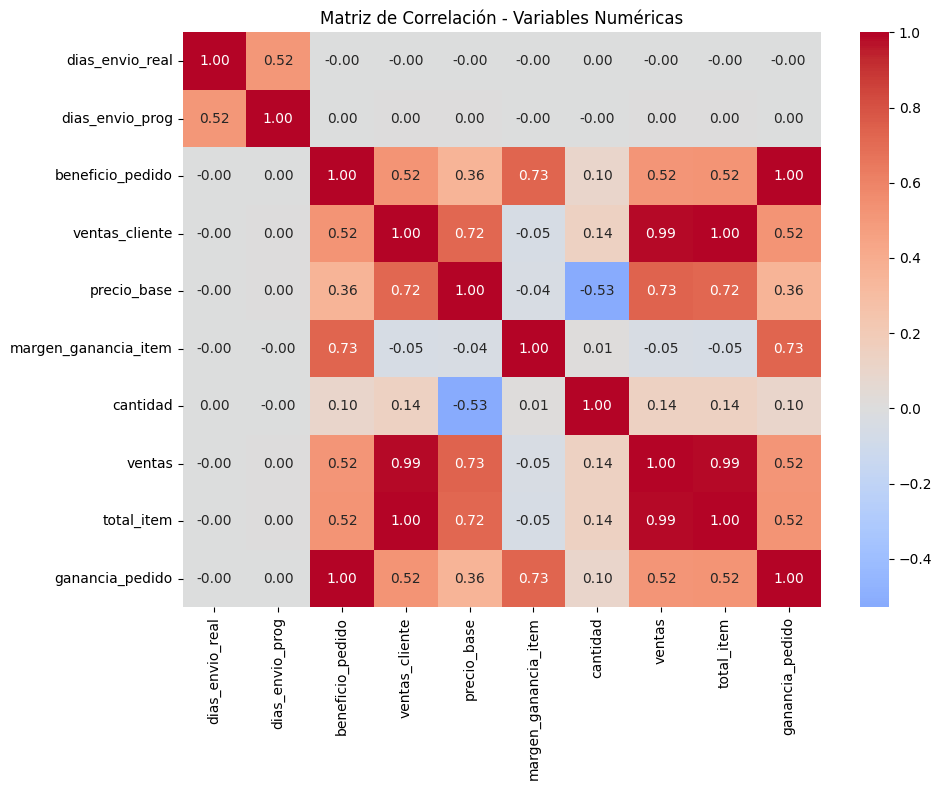

Variables con alta correlación (>0.7):
  beneficio_pedido - margen_ganancia_item: 0.73
  beneficio_pedido - ganancia_pedido: 1.00
  ventas_cliente - precio_base: 0.72
  ventas_cliente - ventas: 0.99
  ventas_cliente - total_item: 1.00
  precio_base - ventas: 0.73
  precio_base - total_item: 0.72
  margen_ganancia_item - ganancia_pedido: 0.73
  ventas - total_item: 0.99


In [17]:
plt.figure(figsize=(10, 8))
correlacion = df_modelo[numericas].corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

alta_corr = [
    (correlacion.columns[i], correlacion.columns[j], correlacion.iloc[i, j])
    for i in range(len(correlacion.columns))
    for j in range(i + 1, len(correlacion.columns))
    if abs(correlacion.iloc[i, j]) > 0.7
]

print("Variables con alta correlación (>0.7):")
for v1, v2, corr in alta_corr:
    print(f"  {v1} - {v2}: {corr:.2f}")

## 13. Resumen de resultados

In [18]:
print("=" * 70)
print("RESUMEN DE RESULTADOS - MODELO NO SUPERVISADO")
print("=" * 70)

print("\n1. PCA:")
print(f"   Componentes para 85% de varianza: {n_componentes}")
print(f"   Varianza explicada por PC1: {varianza_explicada[0]*100:.1f}%")
print(f"   Varianza explicada por PC2: {varianza_explicada[1]*100:.1f}%")

print("\n2. K-Means:")
print(f"   Número óptimo de clusters: {k_optimo}")
print(f"   Silhouette score: {max(silhouette):.4f}")
for c in sorted(df_modelo['cluster_kmeans'].unique()):
    count = (df_modelo['cluster_kmeans'] == c).sum()
    print(f"   Cluster {c}: {count} ({count/len(df_modelo)*100:.1f}%)")

print("\n3. DBSCAN:")
print(f"   eps: {eps_opt}, min_samples: {min_samples_opt}")
print(f"   Clusters: {n_clusters_db}, ruido: {ruido} ({ruido/len(df_pca)*100:.3f}%)")

print("\n4. Anomalías:")
print(f"   K-Means (percentil 95): {sum(anomalias)} ({sum(anomalias)/len(df_modelo)*100:.2f}%)")
print(f"   IQR: {df_modelo['es_outlier'].sum()} ({df_modelo['es_outlier'].sum()/len(df_modelo)*100:.2f}%)")

print("\n5. Variables más importantes:")
for _, row in importancias.head(5).iterrows():
    print(f"   {row['Variable']}: {row['Importancia']:.4f}")

RESUMEN DE RESULTADOS - MODELO NO SUPERVISADO

1. PCA:
   Componentes para 85% de varianza: 10
   Varianza explicada por PC1: 19.3%
   Varianza explicada por PC2: 13.8%

2. K-Means:
   Número óptimo de clusters: 3
   Silhouette score: 0.1631
   Cluster 0: 55425 (36.7%)
   Cluster 1: 66126 (43.8%)
   Cluster 2: 29536 (19.5%)

3. DBSCAN:
   eps: 2.5, min_samples: 15
   Clusters: 7, ruido: 15 (0.010%)

4. Anomalías:
   K-Means (percentil 95): 7555 (5.00%)
   IQR: 536 (0.35%)

5. Variables más importantes:
   dias_envio_real: 0.2647
   dias_envio_prog: 0.1785
   ventas: 0.1717
   ventas_cliente: 0.1037
   total_item: 0.0881


## 14. Interpretación de clusters

In [19]:
print("INTERPRETACIÓN DE CLUSTERS\n")

for cluster in sorted(df_modelo['cluster_kmeans'].unique()):
    datos = df_modelo[df_modelo['cluster_kmeans'] == cluster]
    print(f"CLUSTER {cluster}:")

    beneficio_relativo = "alto" if datos['beneficio_pedido'].mean() > df_modelo['beneficio_pedido'].mean() else "bajo"
    print(f"  Beneficio: {beneficio_relativo}")

    velocidad = "lento" if datos['dias_envio_real'].mean() > df_modelo['dias_envio_real'].mean() else "rápido"
    print(f"  Envío: {velocidad} ({datos['dias_envio_real'].mean():.1f} días en promedio)")

    if 'riesgo_retraso' in datos.columns:
        riesgo = datos['riesgo_retraso'].mean() * 100
        etiqueta = "alto" if riesgo > 50 else "bajo"
        print(f"  Riesgo de retraso: {etiqueta} ({riesgo:.1f}%)")

    # Estado de pedido predominante, decodificado desde la columna original (no un índice mágico)
    estados_cluster = df.loc[datos.index, 'estado_pedido']
    estado_predominante = estados_cluster.value_counts().index[0]
    print(f"  Estado predominante: {estado_predominante}")
    print()

INTERPRETACIÓN DE CLUSTERS

CLUSTER 0:
  Beneficio: bajo
  Envío: rápido (2.8 días en promedio)
  Riesgo de retraso: bajo (0.0%)
  Estado predominante: COMPLETE

CLUSTER 1:
  Beneficio: bajo
  Envío: lento (4.1 días en promedio)
  Riesgo de retraso: alto (100.0%)
  Estado predominante: COMPLETE

CLUSTER 2:
  Beneficio: alto
  Envío: lento (3.5 días en promedio)
  Riesgo de retraso: alto (56.4%)
  Estado predominante: COMPLETE



Se reemplazó la comparación con números mágicos (`estado_pred == 1  # COMPLETE`, que dependía del orden interno de `LabelEncoder`) por una lectura directa de la columna original del DataFrame, evitando que un futuro cambio en la codificación rompa silenciosamente esta lógica.

## 15. Recomendaciones para el modelo supervisado

RECOMENDACIONES PARA EL MODELO SUPERVISADO

1. Variables recomendadas:
   - dias_envio_real
   - dias_envio_prog
   - ventas
   - ventas_cliente
   - total_item
   - precio_base

2. Estrategia de modelado:
   - Usar 'cluster_kmeans' como feature adicional
   - Prestar especial atención al Cluster de alto valor (mayor beneficio y ventas)
   - Validar el modelo por región y modo de envío

3. Mejoras sugeridas:
   - Incorporar variables temporales (estacionalidad)
   - Analizar clusters por región geográfica
   - Evaluar el impacto del modo de envío en el riesgo de retraso

4. Integración con MongoDB:
   - Guardar la etiqueta de cluster por pedido
   - Almacenar resultados de detección de anomalías
   - Usar documentos enriquecidos con el perfil de cada cluster

### Estructura de documento para MongoDB

In [22]:
import json
from datetime import date

# Perfil resumido por cluster, calculado a partir de los datos reales (no hardcodeado)
perfiles_cluster = {}
for cluster in sorted(df_modelo['cluster_kmeans'].unique()):
    datos = df_modelo[df_modelo['cluster_kmeans'] == cluster]
    perfiles_cluster[int(cluster)] = {
        'tipo': 'alto_valor' if datos['beneficio_pedido'].mean() > df_modelo['beneficio_pedido'].mean() else 'estandar',
        'riesgo': 'alto' if datos['riesgo_retraso'].mean() > 0.5 else 'bajo',
    }

fila_ejemplo = df_final.iloc[0]
cluster_ejemplo = int(fila_ejemplo['cluster_kmeans'])

documento_ejemplo = {
    'estado_pedido': fila_ejemplo['estado_pedido'],
    'tipo_transaccion': fila_ejemplo['tipo_transaccion'],
    'dias_envio_real': int(fila_ejemplo['dias_envio_real']),
    'dias_envio_prog': int(fila_ejemplo['dias_envio_prog']),
    'beneficio_pedido': float(fila_ejemplo['beneficio_pedido']),
    'ventas_cliente': float(fila_ejemplo['ventas_cliente']),
    'categoria': fila_ejemplo['categoria'],
    'modo_envio': fila_ejemplo['modo_envio'],
    'cluster_kmeans': cluster_ejemplo,
    'cluster_dbscan': int(fila_ejemplo['cluster_dbscan']),
    'es_anomalia': bool(fila_ejemplo['es_anomalia']),
    'es_outlier': bool(fila_ejemplo['es_outlier']),
    'perfil_cluster': perfiles_cluster[cluster_ejemplo],
    'metadatos_analisis': {
        'fecha_analisis': str(date.today()),
        'version_modelo': '2.0'
    }
}

print(json.dumps(documento_ejemplo, indent=2, default=str, ensure_ascii=False))

{
  "estado_pedido": "COMPLETE",
  "tipo_transaccion": "DEBIT",
  "dias_envio_real": 3,
  "dias_envio_prog": 4,
  "beneficio_pedido": 91.25,
  "ventas_cliente": 314.6400146484375,
  "categoria": "Sporting Goods",
  "modo_envio": "Standard Class",
  "cluster_kmeans": 2,
  "cluster_dbscan": 0,
  "es_anomalia": false,
  "es_outlier": false,
  "perfil_cluster": {
    "tipo": "alto_valor",
    "riesgo": "alto"
  },
  "metadatos_analisis": {
    "fecha_analisis": "2026-07-08",
    "version_modelo": "2.0"
  }
}
